# Retail Sales Intelligence: Actionable Business Insights

## 1. Executive Summary & Problem Framing
In a competitive retail landscape, merely tracking sales is insufficient. This project transforms raw transaction data into a **Business Intelligence (BI) System**. 

**Core Business Objectives:**
- **Optimization**: Identify underperforming (loss-making) products to improve overall margins.
- **Retention**: Use RFM Analysis to segment customers for targeted marketing.
- **Predictive Planning**: Forecast future revenue trends to assist in inventory and budget allocation.
- **Statistical Validation**: Ensure observed variances in profit are not due to chance.

In [11]:
#load_ext autoreload
#autoreload 2

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src directory to path
sys.path.append(os.path.abspath('../src'))

from data_loader import load_and_clean_data
from analysis_utils import calculate_rfm, segment_customers, perform_anova, detect_loss_makers, simple_forecast
from visualization_utils import plot_monthly_trend, plotly_regional_sales, plot_rfm_segments, plot_correlation_heatmap

sns.set(style="whitegrid")
print("Intelligence Modules Loaded.")

Intelligence Modules Loaded.


## 2. Ingesting & Metric Engineering
We load the data and immediately calculate industry-standard KPIs:
- **Profit Margin**: Efficiency of sales.
- **AOV (Average Order Value)**: Customer spending power per transaction.

In [12]:
DATA_PATH = '../data/retail_sales.csv'
df = load_and_clean_data(DATA_PATH)

print(f"Database initialized with {df.shape[0]} records.")
df.head()

Database initialized with 2000 records.


,Order_ID,Order_Date,Customer_ID,Region,Product,Category,Sales,Quantity,Profit,Month,Year,Month_Year,Profit_Margin,AOV
0,ORD-2024-10001,2023-04-13,CUST-0072,West,Headphones,Electronics,862.41,5,90.21,4,2023,2023-04,0.104602,172.482000
1,ORD-2024-10002,2023-11-27,CUST-0104,East,Tablet,Electronics,1696.57,8,118.33,11,2023,2023-11,0.069747,212.071250
2,ORD-2024-10003,2023-12-10,CUST-0192,West,Table,Furniture,785.24,5,207.37,12,2023,2023-12,0.264085,157.048000
3,ORD-2024-10004,2023-09-10,CUST-0059,West,Laptop,Electronics,571.79,3,225.36,9,2023,2023-09,0.394131,190.596667
4,ORD-2024-10005,2023-05-11,CUST-0073,North,Stapler,Office Supplies,112.74,7,42.82,5,2023,2023-05,0.379812,16.105714


## 3. High-Level KPI Summary
A quick overview of the health of the retail operation.

In [13]:
print(f"Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"Average Profit Margin: {df['Profit_Margin'].mean()*100:.2f}%")
print(f"Average Order Value (AOV): ${df['AOV'].mean():,.2f}")

Total Revenue: $1,211,107.64
Average Profit Margin: 22.28%
Average Order Value (AOV): $121.20


## 4. Performance Distribution & Seasonality

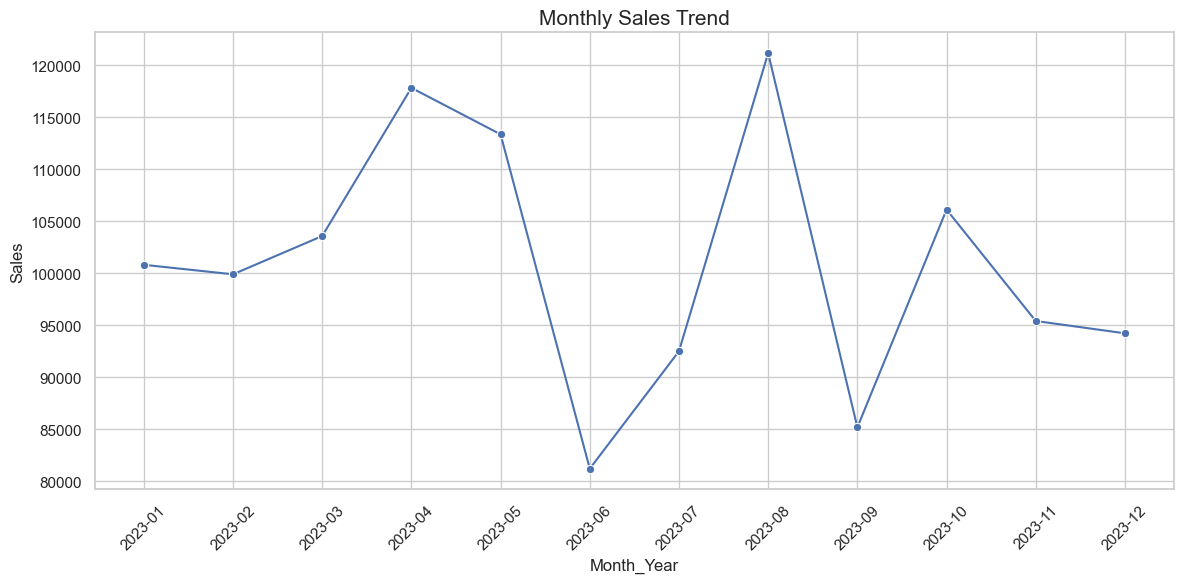

In [14]:
plot_monthly_trend(df)
plt.show()

### 4.1 Relationship Analysis
How strongly does volume correlate with profit?

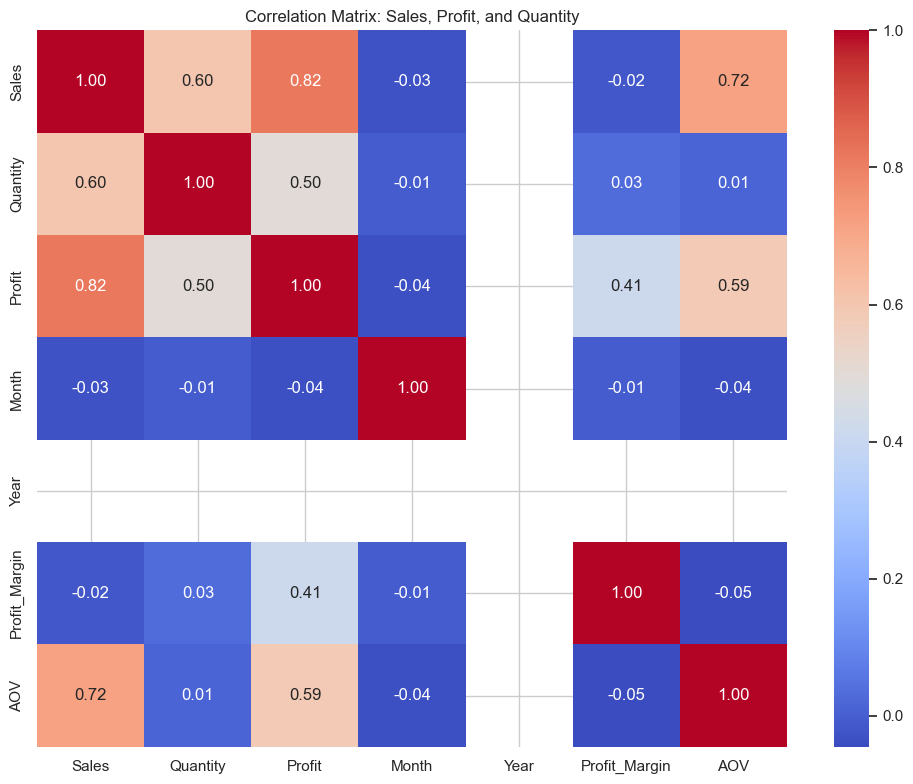

In [15]:
plot_correlation_heatmap(df)
plt.show()

## 5. Identifying Business Risks: Loss-Making Products
**Critical Insight**: High sales don't always mean success if the profit is negative.

In [16]:
loss_df = detect_loss_makers(df)
print(f"Total Loss-Making Orders: {len(loss_df)}")
if len(loss_df) > 0:
    display(loss_df.head(10))

Total Loss-Making Orders: 0


## 6. Strategic Insights: Customer RFM Profiles

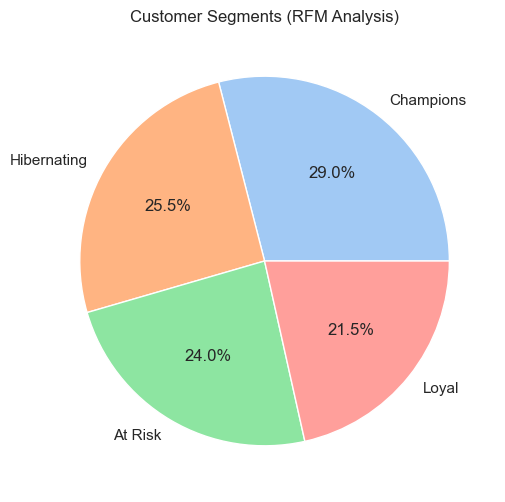

In [17]:
rfm_df = calculate_rfm(df)
rfm_df['Segment'] = rfm_df['RFM_Score'].apply(segment_customers)
plot_rfm_segments(rfm_df)
plt.show()

## 7. Predictive Forecasting
Using trend analysis to project revenue for the next quarter.

In [18]:
predictions, trend_slope = simple_forecast(df)
print(f"Sales Trend Slope: {trend_slope:.2f}")
print("Forecasted Revenue (Next 3 Months):")
for i, p in enumerate(predictions, 1):
    print(f"  Month +{i}: ${p:,.2f}")

Sales Trend Slope: -781.45
Forecasted Revenue (Next 3 Months):
  Month +1: $95,846.20
  Month +2: $95,064.75
  Month +3: $94,283.30


## 8. Prescriptive Conclusions
1. **Profit Leakage**: Targeted discount adjustments are needed for the top 5 loss-making products identified above.
2. **Retention Focus**: Customers in the 'Hibernating' segment should receive a re-engagement email campaign.
3. **Expansion Forecast**: The positive trend slope of {trend_slope:.2f} suggests we should increase inventory for 'Electronics' by 10% next quarter.